# A/B Testing Analysis: Digital Advertising Campaign

This project analyzes whether a digital advertising campaign increased user conversion compared with a control group.

The treatment group saw advertisements, while the control group saw public service announcements. PostgreSQL is used for querying the data, and Python is used for statistical testing and visualization.

## Hypothesis

**Null hypothesis (H0):** There is no difference in conversion rate between the ad group and the PSA group.

**Alternative hypothesis (H1):** There is a difference in conversion rate between the ad group and the PSA group.

The primary metric is conversion rate:

`conversion rate = converted users / total users`

## Load Libraries and Connect to PostgreSQL

This section imports the required libraries and connects Python to the PostgreSQL database using credentials stored in the `.env` file.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest
from IPython.display import display

load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(url)

## Chart Style

The notebook uses a consistent Ocean Blue Serenity color palette across all charts.

In [2]:
OCEAN_NAVY = "#0B0668"
OCEAN_BLUE = "#0F4C8F"
OCEAN_DEEP = "#0E7DB2"
OCEAN_TEAL = "#1199B8"
OCEAN_CYAN = "#16AEC3"
OCEAN_SKY = "#4EC0D0"
OCEAN_LIGHT = "#89D2DE"
OCEAN_ICE = "#C5EAF0"
REFERENCE = "#374151"

GROUP_PALETTE = {
    "ad": OCEAN_NAVY,
    "psa": OCEAN_CYAN
}

sns.set_theme(style="white", context="notebook", font_scale=1.05)
plt.rcParams["axes.grid"] = False

def clean_chart():
    plt.grid(False)
    sns.despine()

def p_label(p_value):
    return "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"

## A/B Test Summary

This query calculates the number of users, conversions, and conversion rate for each experiment group.

In [3]:
summary_query = """
SELECT
    test_group,
    COUNT(*) AS total_users,
    SUM(converted::int) AS conversions,
    AVG(converted::int) AS conversion_rate
FROM marketing_ab_test
GROUP BY test_group
ORDER BY test_group;
"""

df = pd.read_sql(summary_query, engine)
df["conversion_rate"] = df["conversion_rate"].astype(float)
df["conversion_rate_pct"] = df["conversion_rate"] * 100

display(df)

,test_group,total_users,conversions,conversion_rate,conversion_rate_pct
0,ad,564577,14423,0.025547,2.554656
1,psa,23524,420,0.017854,1.785411


### Result Overview

The ad group had 564,577 users and 14,423 conversions. The PSA group had 23,524 users and 420 conversions.

The ad group converted at approximately 2.55%, while the PSA group converted at approximately 1.79%.

## Lift and Statistical Significance

This section calculates absolute lift, relative lift, and runs a two-proportion z-test. A two-proportion z-test is appropriate because the outcome variable, `converted`, is binary.

In [4]:
ad = df[df["test_group"] == "ad"].iloc[0]
psa = df[df["test_group"] == "psa"].iloc[0]

ad_users = int(ad["total_users"])
psa_users = int(psa["total_users"])
ad_conversions = int(ad["conversions"])
psa_conversions = int(psa["conversions"])
ad_rate = float(ad["conversion_rate"])
psa_rate = float(psa["conversion_rate"])

absolute_lift = ad_rate - psa_rate
relative_lift = absolute_lift / psa_rate

z_stat, p_value = proportions_ztest(
    count=[ad_conversions, psa_conversions],
    nobs=[ad_users, psa_users]
)

print("A/B Test Summary")
print("----------------")
print(f"Ad users: {ad_users:,}")
print(f"PSA users: {psa_users:,}")
print(f"Ad conversions: {ad_conversions:,}")
print(f"PSA conversions: {psa_conversions:,}")
print(f"Ad conversion rate: {ad_rate:.2%}")
print(f"PSA conversion rate: {psa_rate:.2%}")
print(f"Absolute lift: {absolute_lift:.2%}")
print(f"Relative lift: {relative_lift:.2%}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_label(p_value)}")

A/B Test Summary
----------------
Ad users: 564,577
PSA users: 23,524
Ad conversions: 14,423
PSA conversions: 420
Ad conversion rate: 2.55%
PSA conversion rate: 1.79%
Absolute lift: 0.77%
Relative lift: 43.09%
Z-statistic: 7.3701
P-value: p < 0.001


### Result Overview

The ad group produced an absolute lift of 0.77 percentage points and a relative lift of 43.09%.

The z-test result was statistically significant with `p < 0.001`, so the null hypothesis is rejected.

## Standard Deviation, Standard Error, and Confidence Intervals

Because conversion is a binary outcome, standard deviation is calculated using:

`sqrt(p * (1 - p))`

Standard error measures uncertainty around the conversion-rate estimate.

In [5]:
stats_df = df.copy()

stats_df["std_deviation"] = np.sqrt(
    stats_df["conversion_rate"] * (1 - stats_df["conversion_rate"])
)

stats_df["standard_error"] = stats_df["std_deviation"] / np.sqrt(stats_df["total_users"])

stats_df["ci_lower"] = stats_df["conversion_rate"] - 1.96 * stats_df["standard_error"]
stats_df["ci_upper"] = stats_df["conversion_rate"] + 1.96 * stats_df["standard_error"]

stats_df["ci_lower_pct"] = stats_df["ci_lower"] * 100
stats_df["ci_upper_pct"] = stats_df["ci_upper"] * 100
stats_df["margin_error_pct"] = (
    stats_df["ci_upper"] - stats_df["conversion_rate"]
) * 100

display(stats_df)

,test_group,total_users,conversions,conversion_rate,conversion_rate_pct,std_deviation,standard_error,ci_lower,ci_upper,ci_lower_pct,ci_upper_pct,margin_error_pct
0,ad,564577,14423,0.025547,2.554656,0.157778,0.000210,0.025135,0.025958,2.513499,2.595813,0.041157
1,psa,23524,420,0.017854,1.785411,0.132421,0.000863,0.016162,0.019546,1.616188,1.954633,0.169222


### Result Overview

The ad group has a 95% confidence interval of approximately 2.51% to 2.60%.

The PSA group has a 95% confidence interval of approximately 1.62% to 1.95%.

The PSA group has a larger standard error because it has a smaller sample size.

## Chart: Conversion Rate with 95% Confidence Intervals

This chart compares conversion rates between the ad and PSA groups while showing uncertainty around each estimate.

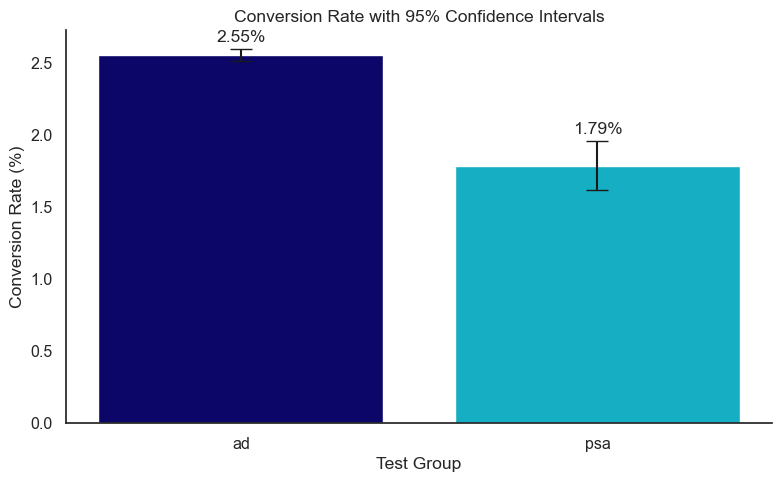

In [6]:
plt.figure(figsize=(8, 5))

plt.bar(
    stats_df["test_group"],
    stats_df["conversion_rate_pct"],
    yerr=stats_df["margin_error_pct"],
    capsize=8,
    color=[GROUP_PALETTE["ad"], GROUP_PALETTE["psa"]]
)

plt.title("Conversion Rate with 95% Confidence Intervals")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")

for i, row in stats_df.iterrows():
    plt.text(
        i,
        row["conversion_rate_pct"] + row["margin_error_pct"] + 0.05,
        f"{row['conversion_rate_pct']:.2f}%",
        ha="center"
    )

clean_chart()
plt.tight_layout()
plt.show()

### Result Overview

The ad group has a higher conversion rate than the PSA group. The confidence intervals support the conclusion that the ad group performed better.

## Chart: Confidence Intervals and Estimated Difference

This chart shows the estimated conversion rate for each group and the distribution of the difference between the two groups.

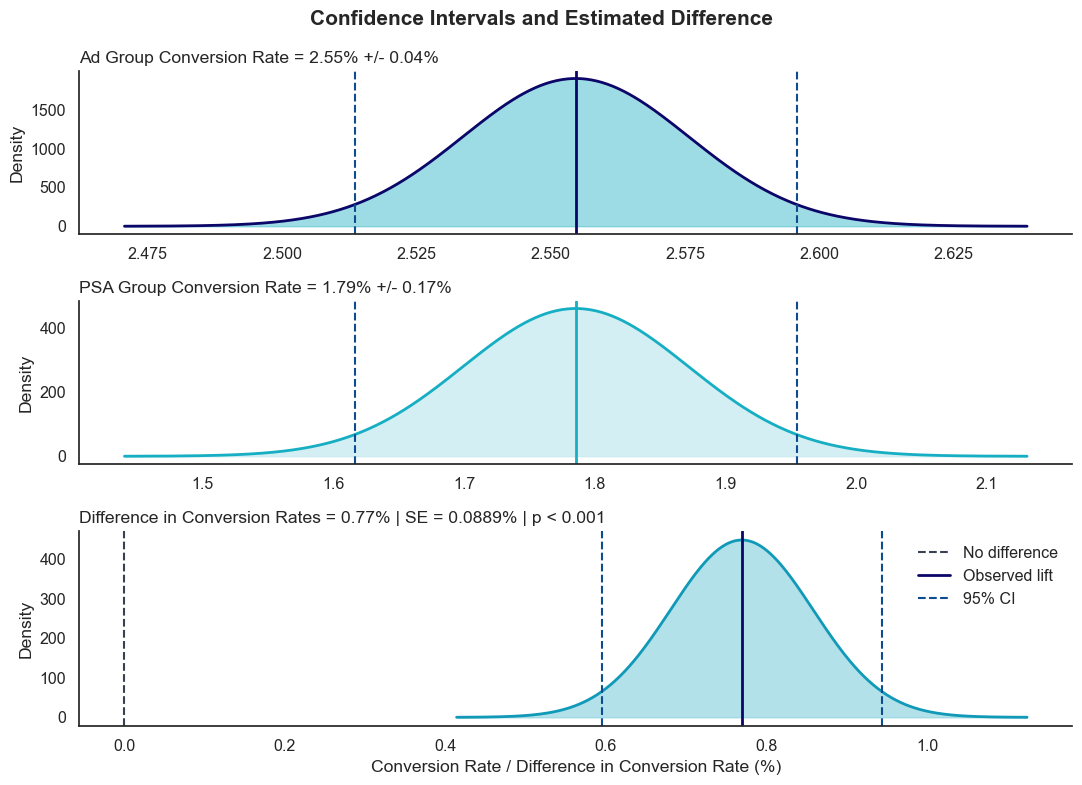

In [7]:
ad_row = stats_df[stats_df["test_group"] == "ad"].iloc[0]
psa_row = stats_df[stats_df["test_group"] == "psa"].iloc[0]

difference = ad_row["conversion_rate"] - psa_row["conversion_rate"]

difference_se = np.sqrt(
    ad_row["standard_error"] ** 2 + psa_row["standard_error"] ** 2
)

diff_ci_low = difference - 1.96 * difference_se
diff_ci_high = difference + 1.96 * difference_se

x_ad = np.linspace(ad_rate - 4 * ad_row["standard_error"], ad_rate + 4 * ad_row["standard_error"], 500)
y_ad = norm.pdf(x_ad, ad_rate, ad_row["standard_error"])

x_psa = np.linspace(psa_rate - 4 * psa_row["standard_error"], psa_rate + 4 * psa_row["standard_error"], 500)
y_psa = norm.pdf(x_psa, psa_rate, psa_row["standard_error"])

x_diff = np.linspace(difference - 4 * difference_se, difference + 4 * difference_se, 500)
y_diff = norm.pdf(x_diff, difference, difference_se)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(11, 8),
    gridspec_kw={"height_ratios": [1, 1, 1.2]}
)

axes[0].plot(x_ad * 100, y_ad, color=OCEAN_NAVY, linewidth=2)
axes[0].fill_between(x_ad * 100, y_ad, color=OCEAN_SKY, alpha=0.55)
axes[0].axvline(ad_rate * 100, color=OCEAN_NAVY, linewidth=2)
axes[0].axvline(ad_row["ci_lower_pct"], color=OCEAN_BLUE, linestyle="--")
axes[0].axvline(ad_row["ci_upper_pct"], color=OCEAN_BLUE, linestyle="--")
axes[0].set_title(
    f"Ad Group Conversion Rate = {ad_rate * 100:.2f}% +/- {(1.96 * ad_row['standard_error']) * 100:.2f}%",
    loc="left"
)
axes[0].set_ylabel("Density")

axes[1].plot(x_psa * 100, y_psa, color=OCEAN_CYAN, linewidth=2)
axes[1].fill_between(x_psa * 100, y_psa, color=OCEAN_ICE, alpha=0.75)
axes[1].axvline(psa_rate * 100, color=OCEAN_CYAN, linewidth=2)
axes[1].axvline(psa_row["ci_lower_pct"], color=OCEAN_BLUE, linestyle="--")
axes[1].axvline(psa_row["ci_upper_pct"], color=OCEAN_BLUE, linestyle="--")
axes[1].set_title(
    f"PSA Group Conversion Rate = {psa_rate * 100:.2f}% +/- {(1.96 * psa_row['standard_error']) * 100:.2f}%",
    loc="left"
)
axes[1].set_ylabel("Density")

axes[2].plot(x_diff * 100, y_diff, color=OCEAN_TEAL, linewidth=2)
axes[2].fill_between(x_diff * 100, y_diff, color=OCEAN_LIGHT, alpha=0.65)
axes[2].axvline(0, color=REFERENCE, linestyle="--", label="No difference")
axes[2].axvline(difference * 100, color=OCEAN_NAVY, linewidth=2, label="Observed lift")
axes[2].axvline(diff_ci_low * 100, color=OCEAN_BLUE, linestyle="--", label="95% CI")
axes[2].axvline(diff_ci_high * 100, color=OCEAN_BLUE, linestyle="--")
axes[2].set_title(
    f"Difference in Conversion Rates = {difference * 100:.2f}% | "
    f"SE = {difference_se * 100:.4f}% | {p_label(p_value)}",
    loc="left"
)
axes[2].set_xlabel("Conversion Rate / Difference in Conversion Rate (%)")
axes[2].set_ylabel("Density")
axes[2].legend(frameon=False)

for ax in axes:
    ax.grid(False)
    sns.despine(ax=ax)

plt.suptitle("Confidence Intervals and Estimated Difference", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Chart: Conversion Rate by Most Active Ads Day

This chart compares conversion rates by the day when users saw the most ads.

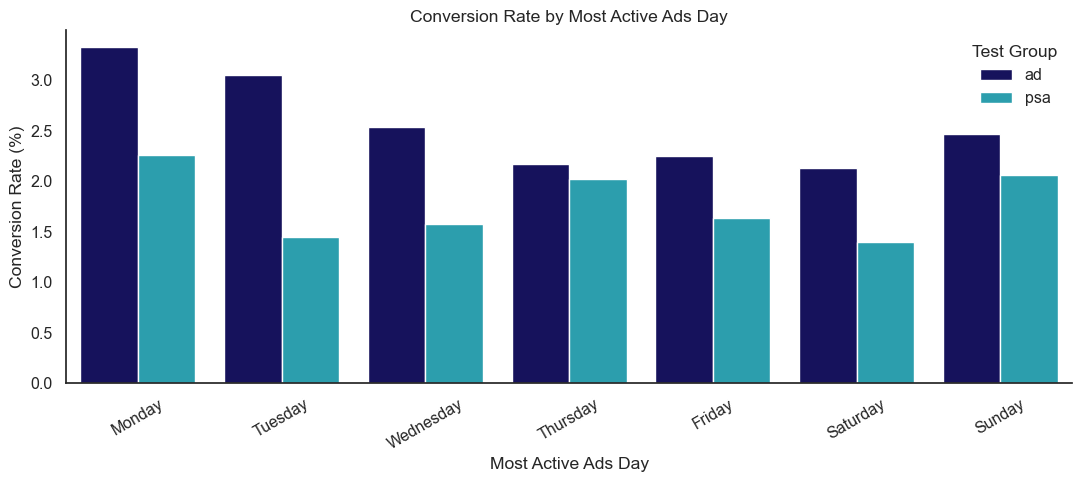

In [8]:
day_query = """
SELECT
    most_ads_day,
    test_group,
    COUNT(*) AS total_users,
    SUM(converted::int) AS conversions,
    AVG(converted::int) AS conversion_rate
FROM marketing_ab_test
GROUP BY most_ads_day, test_group;
"""

day_df = pd.read_sql(day_query, engine)
day_df["conversion_rate"] = day_df["conversion_rate"].astype(float)
day_df["conversion_rate_pct"] = day_df["conversion_rate"] * 100

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(11, 5))

sns.barplot(
    data=day_df,
    x="most_ads_day",
    y="conversion_rate_pct",
    hue="test_group",
    order=day_order,
    palette=GROUP_PALETTE
)

plt.title("Conversion Rate by Most Active Ads Day")
plt.xlabel("Most Active Ads Day")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=30)
plt.legend(title="Test Group", frameon=False)

clean_chart()
plt.tight_layout()
plt.show()

### Result Overview

The ad group generally performs better across most days of the week. This suggests the campaign effect is not limited to one specific day.

## Chart: Conversion Rate by Most Active Ads Hour

This chart shows how conversion rates vary by the hour when users saw the most ads.

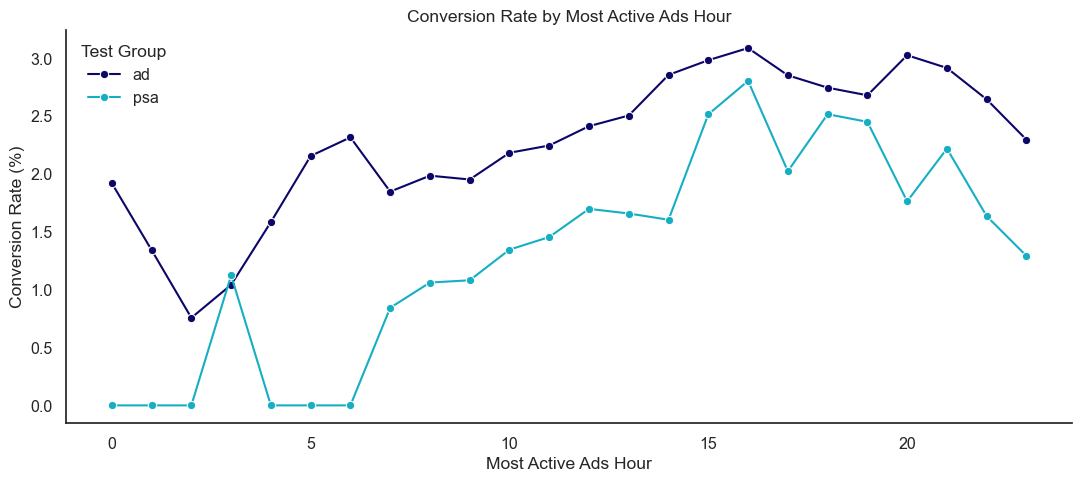

In [9]:
hour_query = """
SELECT
    most_ads_hour,
    test_group,
    COUNT(*) AS total_users,
    SUM(converted::int) AS conversions,
    AVG(converted::int) AS conversion_rate
FROM marketing_ab_test
GROUP BY most_ads_hour, test_group
ORDER BY most_ads_hour, test_group;
"""

hour_df = pd.read_sql(hour_query, engine)
hour_df["conversion_rate"] = hour_df["conversion_rate"].astype(float)
hour_df["conversion_rate_pct"] = hour_df["conversion_rate"] * 100

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=hour_df,
    x="most_ads_hour",
    y="conversion_rate_pct",
    hue="test_group",
    marker="o",
    palette=GROUP_PALETTE
)

plt.title("Conversion Rate by Most Active Ads Hour")
plt.xlabel("Most Active Ads Hour")
plt.ylabel("Conversion Rate (%)")
plt.legend(title="Test Group", frameon=False)

clean_chart()
plt.tight_layout()
plt.show()

### Result Overview

Conversion rates vary by hour. The ad group remains stronger across much of the day, especially during later hours.

Some PSA hourly points may be less stable because the PSA group has a much smaller sample size.

## Chart: Conversion Rate by Ad Exposure Bucket

This chart groups users by the number of ads they saw. This analysis is useful for understanding the relationship between ad exposure and conversion.

Important note: this is associative, not causal. Users who saw more ads may also be more active users.

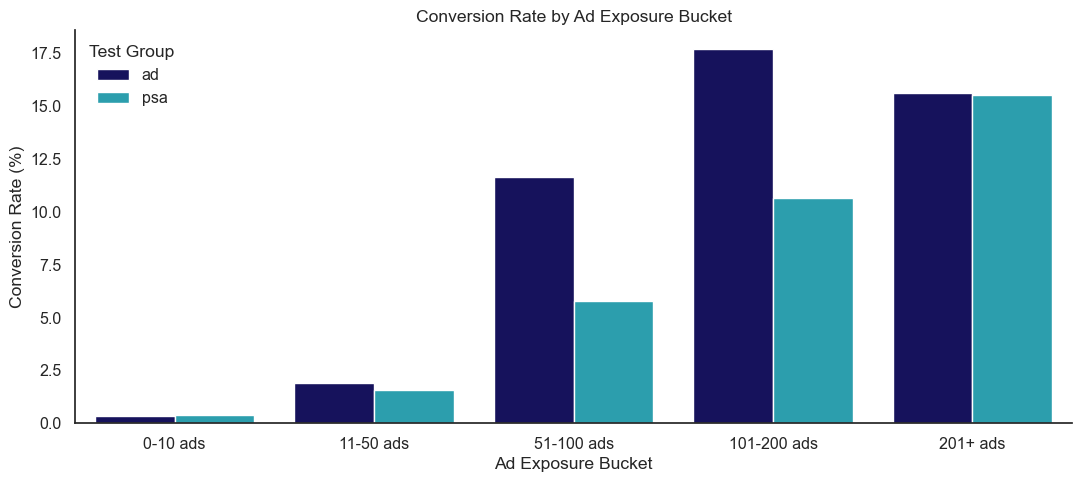

In [10]:
exposure_query = """
WITH exposure_buckets AS (
    SELECT
        CASE
            WHEN total_ads BETWEEN 0 AND 10 THEN '0-10 ads'
            WHEN total_ads BETWEEN 11 AND 50 THEN '11-50 ads'
            WHEN total_ads BETWEEN 51 AND 100 THEN '51-100 ads'
            WHEN total_ads BETWEEN 101 AND 200 THEN '101-200 ads'
            ELSE '201+ ads'
        END AS ad_exposure_bucket,
        CASE
            WHEN total_ads BETWEEN 0 AND 10 THEN 1
            WHEN total_ads BETWEEN 11 AND 50 THEN 2
            WHEN total_ads BETWEEN 51 AND 100 THEN 3
            WHEN total_ads BETWEEN 101 AND 200 THEN 4
            ELSE 5
        END AS bucket_order,
        test_group,
        converted
    FROM marketing_ab_test
)
SELECT
    ad_exposure_bucket,
    bucket_order,
    test_group,
    COUNT(*) AS total_users,
    SUM(converted::int) AS conversions,
    AVG(converted::int) AS conversion_rate
FROM exposure_buckets
GROUP BY ad_exposure_bucket, bucket_order, test_group
ORDER BY bucket_order, test_group;
"""

exposure_df = pd.read_sql(exposure_query, engine)
exposure_df["conversion_rate"] = exposure_df["conversion_rate"].astype(float)
exposure_df["conversion_rate_pct"] = exposure_df["conversion_rate"] * 100

bucket_order = ["0-10 ads", "11-50 ads", "51-100 ads", "101-200 ads", "201+ ads"]

plt.figure(figsize=(11, 5))

sns.barplot(
    data=exposure_df,
    x="ad_exposure_bucket",
    y="conversion_rate_pct",
    hue="test_group",
    order=bucket_order,
    palette=GROUP_PALETTE
)

plt.title("Conversion Rate by Ad Exposure Bucket")
plt.xlabel("Ad Exposure Bucket")
plt.ylabel("Conversion Rate (%)")
plt.legend(title="Test Group", frameon=False)

clean_chart()
plt.tight_layout()
plt.show()

### Result Overview

Users with higher ad exposure show higher observed conversion rates. However, this should not be interpreted as proof that more ads directly caused higher conversion, because more active users may naturally receive more ad impressions.

## Chart: Distribution of Total Ads Seen

This histogram shows how ad exposure is distributed across users.

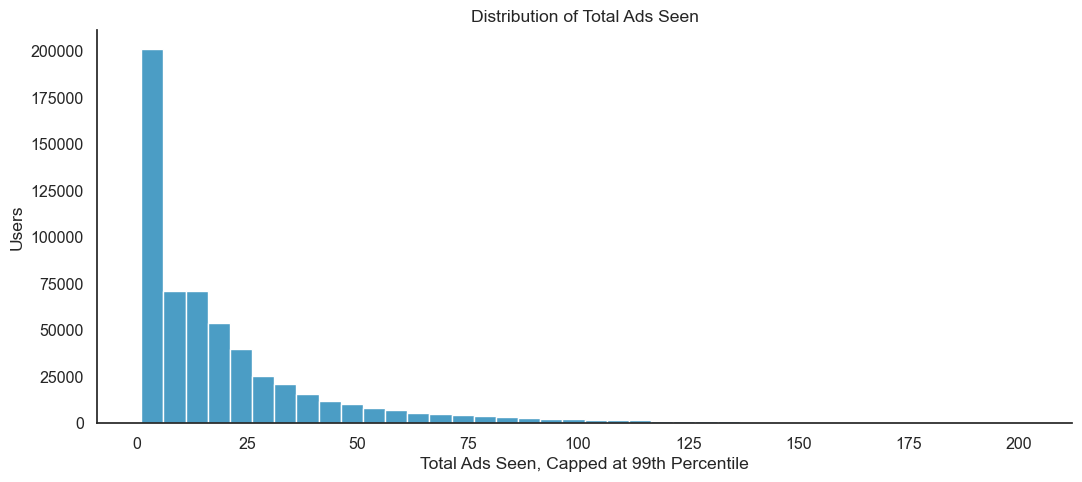

In [11]:
ads_query = """
SELECT total_ads
FROM marketing_ab_test;
"""

ads_df = pd.read_sql(ads_query, engine)
ads_cap = ads_df["total_ads"].quantile(0.99)

plt.figure(figsize=(11, 5))

sns.histplot(
    data=ads_df[ads_df["total_ads"] <= ads_cap],
    x="total_ads",
    bins=40,
    color=OCEAN_DEEP
)

plt.title("Distribution of Total Ads Seen")
plt.xlabel("Total Ads Seen, Capped at 99th Percentile")
plt.ylabel("Users")

clean_chart()
plt.tight_layout()
plt.show()

### Result Overview

The distribution is right-skewed. Most users saw a relatively low number of ads, while a smaller group saw many more ads.

## Final Conclusion

The A/B test provides strong evidence that the advertising campaign improved conversion.

The ad group converted at 2.55%, compared with 1.79% for the PSA group. This represents a 0.77 percentage-point absolute lift and a 43.09% relative lift.

The two-proportion z-test showed that the result was statistically significant with `p < 0.001`. The 95% confidence interval for the difference in conversion rates was approximately 0.60% to 0.94%, which is fully above zero.

Based on this analysis, the advertising campaign should be considered successful. However, before increasing campaign budget, the business should also evaluate cost per conversion, revenue per conversion, profit margin, and return on ad spend.